In [1]:
# 01 EDA
# This notebook explores the rice leaf disease dataset by examining class distribution, sample images, and image resolution characteristics. The goal is to identify dataset imbalance and visual limitations before training the classification model.

In [2]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
# =========================
# CELL 2: LOAD DATA
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
train_df.head()

Train shape: (2684, 4)
Validation shape: (671, 4)


,filepath,label,split,full_path
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...


In [4]:
# =========================
# CELL 3: CLASS DISTRIBUTION
# =========================
print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nValidation class distribution:")
print(val_df["label"].value_counts())

Train class distribution:
label
Healthy      1191
LeafBlast     623
Hispa         452
BrownSpot     418
Name: count, dtype: int64

Validation class distribution:
label
Healthy      297
LeafBlast    156
Hispa        113
BrownSpot    105
Name: count, dtype: int64


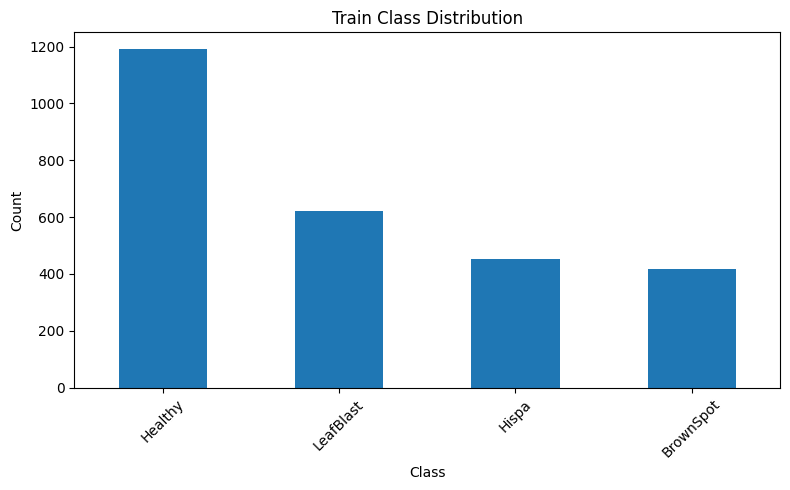

In [5]:
# =========================
# CELL 4: PLOT CLASS DISTRIBUTION
# =========================
class_counts = train_df["label"].value_counts()

if len(class_counts) == 0:
    print("No training data found. Check file paths.")
else:
    class_counts.plot(kind="bar", figsize=(8, 5), title="Train Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

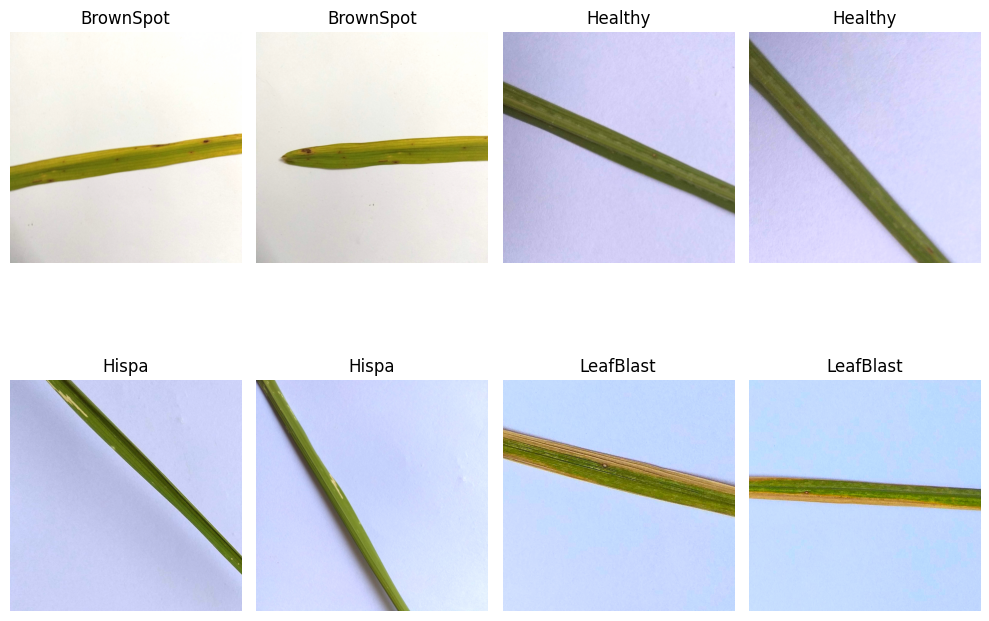

In [6]:
# =========================
# CELL 5: SHOW SAMPLE IMAGES
# =========================
sample_rows = train_df.groupby("label").head(2)

if len(sample_rows) == 0:
    print("No sample images found.")
else:
    plt.figure(figsize=(10, 8))
    for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        img = Image.open(row["full_path"])
        plt.subplot(2, 4, i)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
# =========================
# CELL 6: IMAGE SIZE CHECK
# =========================
sizes = []

for path in train_df["full_path"].sample(min(100, len(train_df)), random_state=42):
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except Exception:
        continue

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
sizes_df.describe()

,width,height
count,100.000000,100.000000
mean,2049.880000,2049.880000
std,613.253557,613.253557
min,1178.000000,1178.000000
25%,1584.500000,1584.500000
50%,1887.500000,1887.500000
75%,2340.000000,2340.000000
max,3120.000000,3120.000000


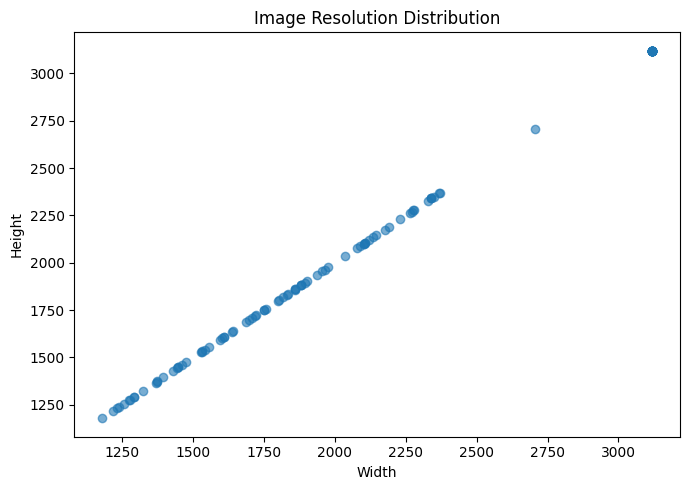

In [8]:
# =========================
# CELL 7: IMAGE SIZE DISTRIBUTION
# =========================
if len(sizes_df) == 0:
    print("No image sizes available.")
else:
    plt.figure(figsize=(7, 5))
    plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.6)
    plt.title("Image Resolution Distribution")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.tight_layout()
    plt.show()